# 1. Median Income Data

In [37]:
import pandas as pd
import shapely
import numpy as np
import fiona
#%pip install --upgrade geopandas shapely
#%pip install --upgrade geopandas fiona
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
os.listdir()

['ACSST1Y2024.S1701-Data.csv',
 'ACSST1Y2024.S1903-Data.csv',
 'ACSST5Y2024.S0802-Data.csv',
 'ACSST5Y2024.S1903-Data.csv',
 'ACSST5Y2024.S2201-Data.csv',
 'cleaned_travis_snap_data.csv',
 'cleaned_travis_snap_data.ipynb',
 'income_data.csv',
 'mapping_travis_snap_data.ipynb',
 'snap_data.csv',
 'snap_retailer_location_data.csv',
 'tl_2024_48_tract.cpg',
 'tl_2024_48_tract.dbf',
 'tl_2024_48_tract.prj',
 'tl_2024_48_tract.shp',
 'tl_2024_48_tract.shp.ea.iso.xml',
 'tl_2024_48_tract.shp.iso.xml',
 'tl_2024_48_tract.shx',
 'travis_heat_maps.ipynb',
 'travis_metropolitan.csv',
 'travis_poverty.csv',
 'Travis_snap_map.png',
 'vehicle_data.csv']

In [38]:
df = pd.read_csv('income_data.csv')
df

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48453000101,Census Tract 1.01; Travis County; Texas,2588,301,2364,304,0,21,0,21,...,47098,22956,154512,100845,94054,75654,37951,27686,143250,87105
2,1400000US48453000102,Census Tract 1.02; Travis County; Texas,1021,118,928,122,0,15,0,15,...,136146,73627,-,**,-,**,-,**,-,**
3,1400000US48453000203,Census Tract 2.03; Travis County; Texas,1246,93,853,144,18,28,16,23,...,76136,27733,115288,107726,114554,21115,93810,35224,147716,31500
4,1400000US48453000204,Census Tract 2.04; Travis County; Texas,1397,144,1039,146,16,24,0,15,...,66458,24195,95833,61014,38882,15038,36218,15818,-,**
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,1400000US48453046700,Census Tract 467; Travis County; Texas,1118,112,716,167,174,166,0,15,...,-,**,-,**,-,**,-,**,-,**
287,1400000US48453046800,Census Tract 468; Travis County; Texas,4549,361,2119,438,630,185,0,23,...,87979,63345,-,**,92315,23007,79271,15908,104521,52197
288,1400000US48453046900,Census Tract 469; Travis County; Texas,2944,340,1678,328,425,220,0,21,...,-,**,73812,1041,166337,18677,165693,47953,-,**
289,1400000US48453047000,Census Tract 470; Travis County; Texas,489,65,364,87,41,49,0,15,...,-,**,-,**,-,**,63707,6001,205926,30071


In [39]:
gdf = gpd.read_file("tl_2024_48_tract.shp")
travis = gdf[gdf["COUNTYFP"] == "453"]

In [40]:
merged = travis.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [41]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

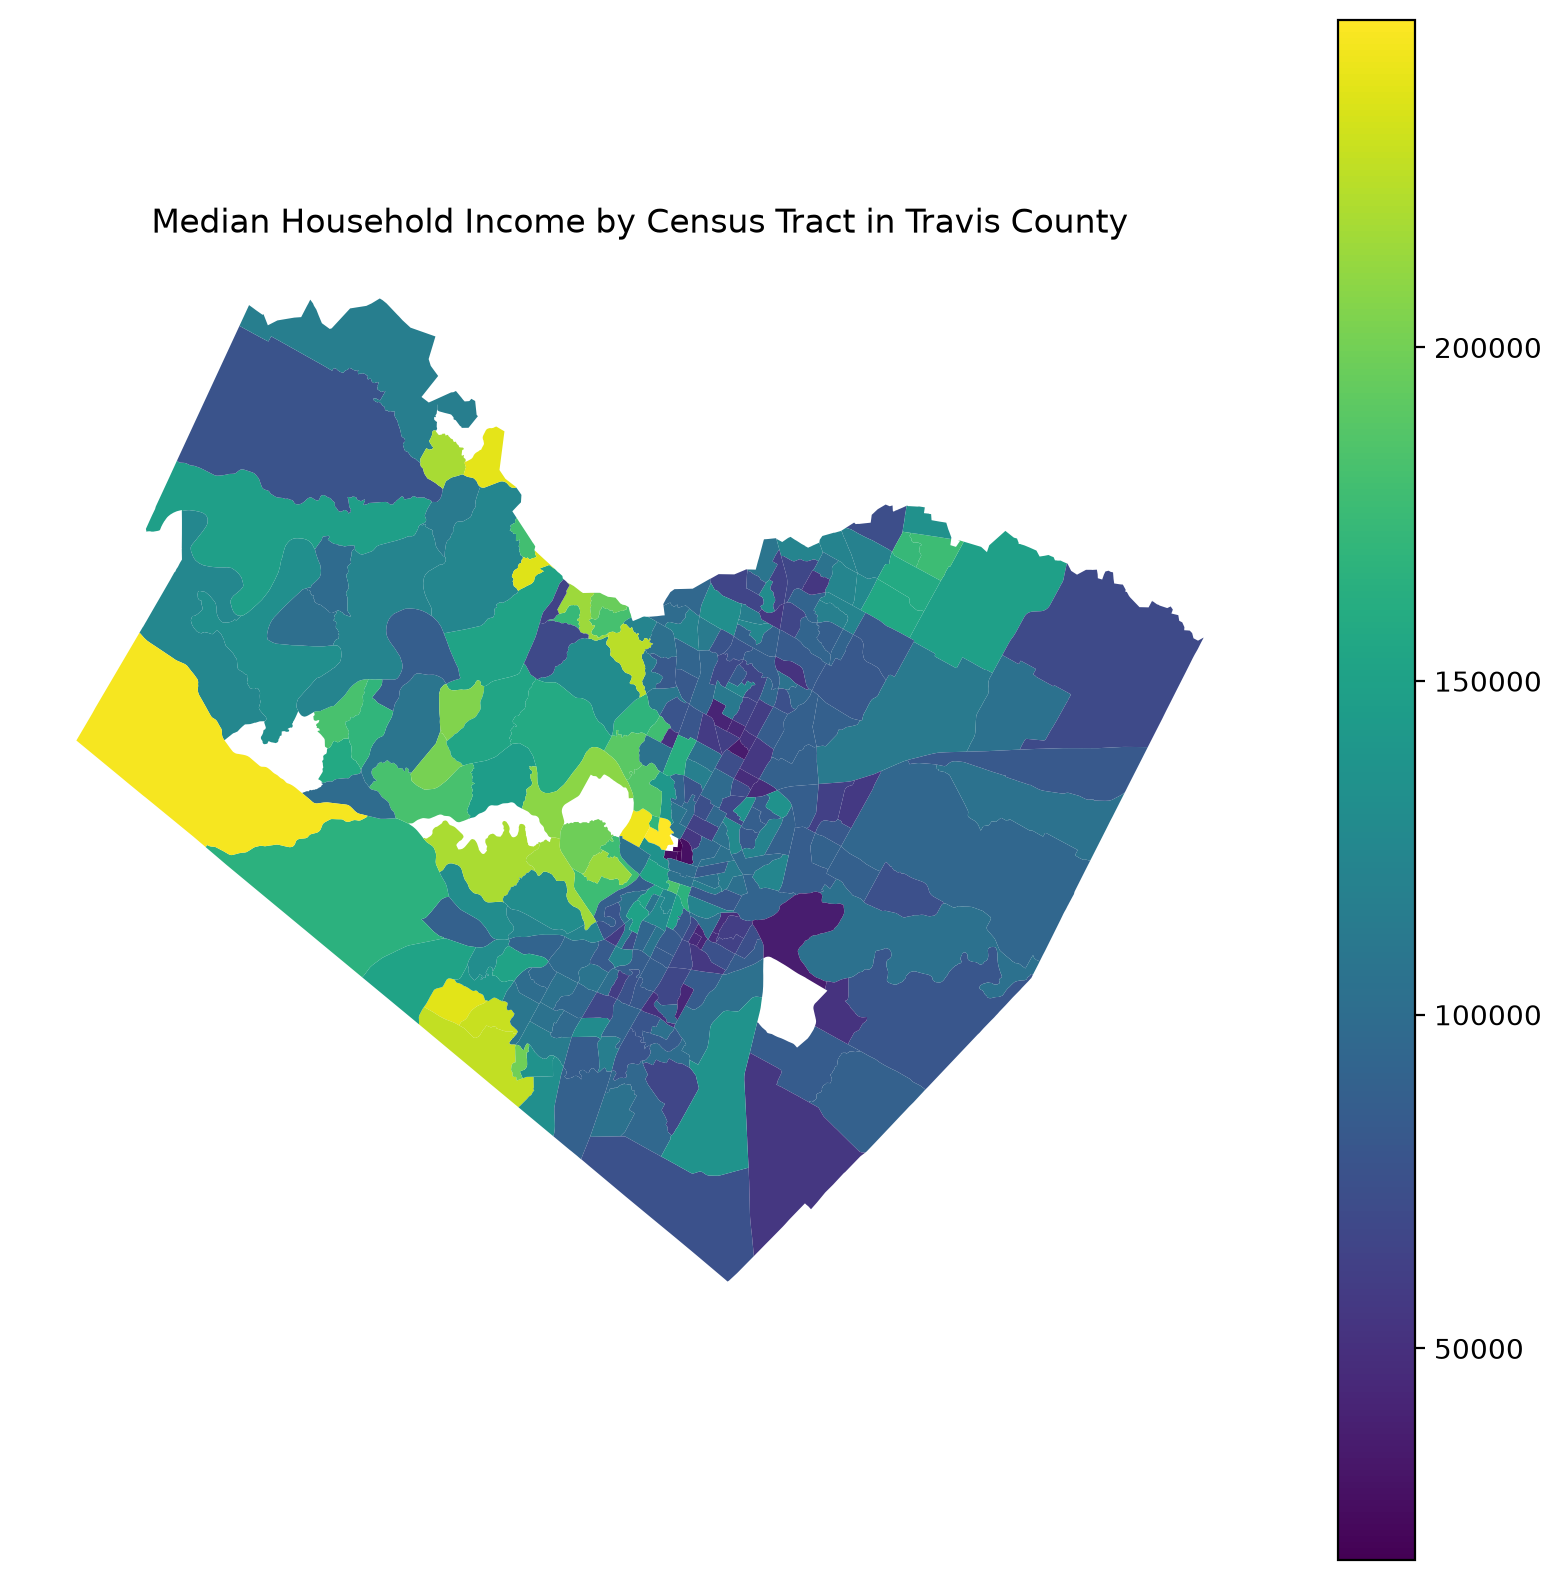

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S1903_C03_001E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Median Household Income by Census Tract in Travis County")
plt.axis("off")
plt.show()

# 2. Mobility Map (No Vehicle Access)

In [43]:
df = pd.read_csv('vehicle_data.csv')
df

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48453000101,Census Tract 1.01; Travis County; Texas,2638,380,1.3,1.2,15,7.7,41.9,9.7,...,12.8,10.1,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48453000102,Census Tract 1.02; Travis County; Texas,1041,200,2.6,2.5,1.1,1.4,24.7,9.8,...,21.1,15.2,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48453000203,Census Tract 2.03; Travis County; Texas,1544,201,5.7,4.3,23.8,7.8,65,7.7,...,0,12.6,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48453000204,Census Tract 2.04; Travis County; Texas,1615,219,0.4,0.7,8,5.1,51.3,7.4,...,17.3,10.2,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,1400000US48453046700,Census Tract 467; Travis County; Texas,1786,187,0.4,0.8,3.6,2.8,37,6.1,...,43,19.2,(X),(X),(X),(X),(X),(X),(X),(X)
287,1400000US48453046800,Census Tract 468; Travis County; Texas,7345,809,3.8,2.6,1,1.1,53.8,6.3,...,17.6,11.5,(X),(X),(X),(X),(X),(X),(X),(X)
288,1400000US48453046900,Census Tract 469; Travis County; Texas,4758,699,2.9,2.2,3.7,2.7,50.7,10,...,17.8,12,(X),(X),(X),(X),(X),(X),(X),(X)
289,1400000US48453047000,Census Tract 470; Travis County; Texas,848,144,2.6,3.1,2.1,1.8,41.6,12.6,...,31.2,25.9,(X),(X),(X),(X),(X),(X),(X),(X)


In [44]:
merged_2 = travis.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

merged_2["S0802_C01_094E"] = pd.to_numeric(
    merged_2["S0802_C01_094E"],
    errors="coerce"
)

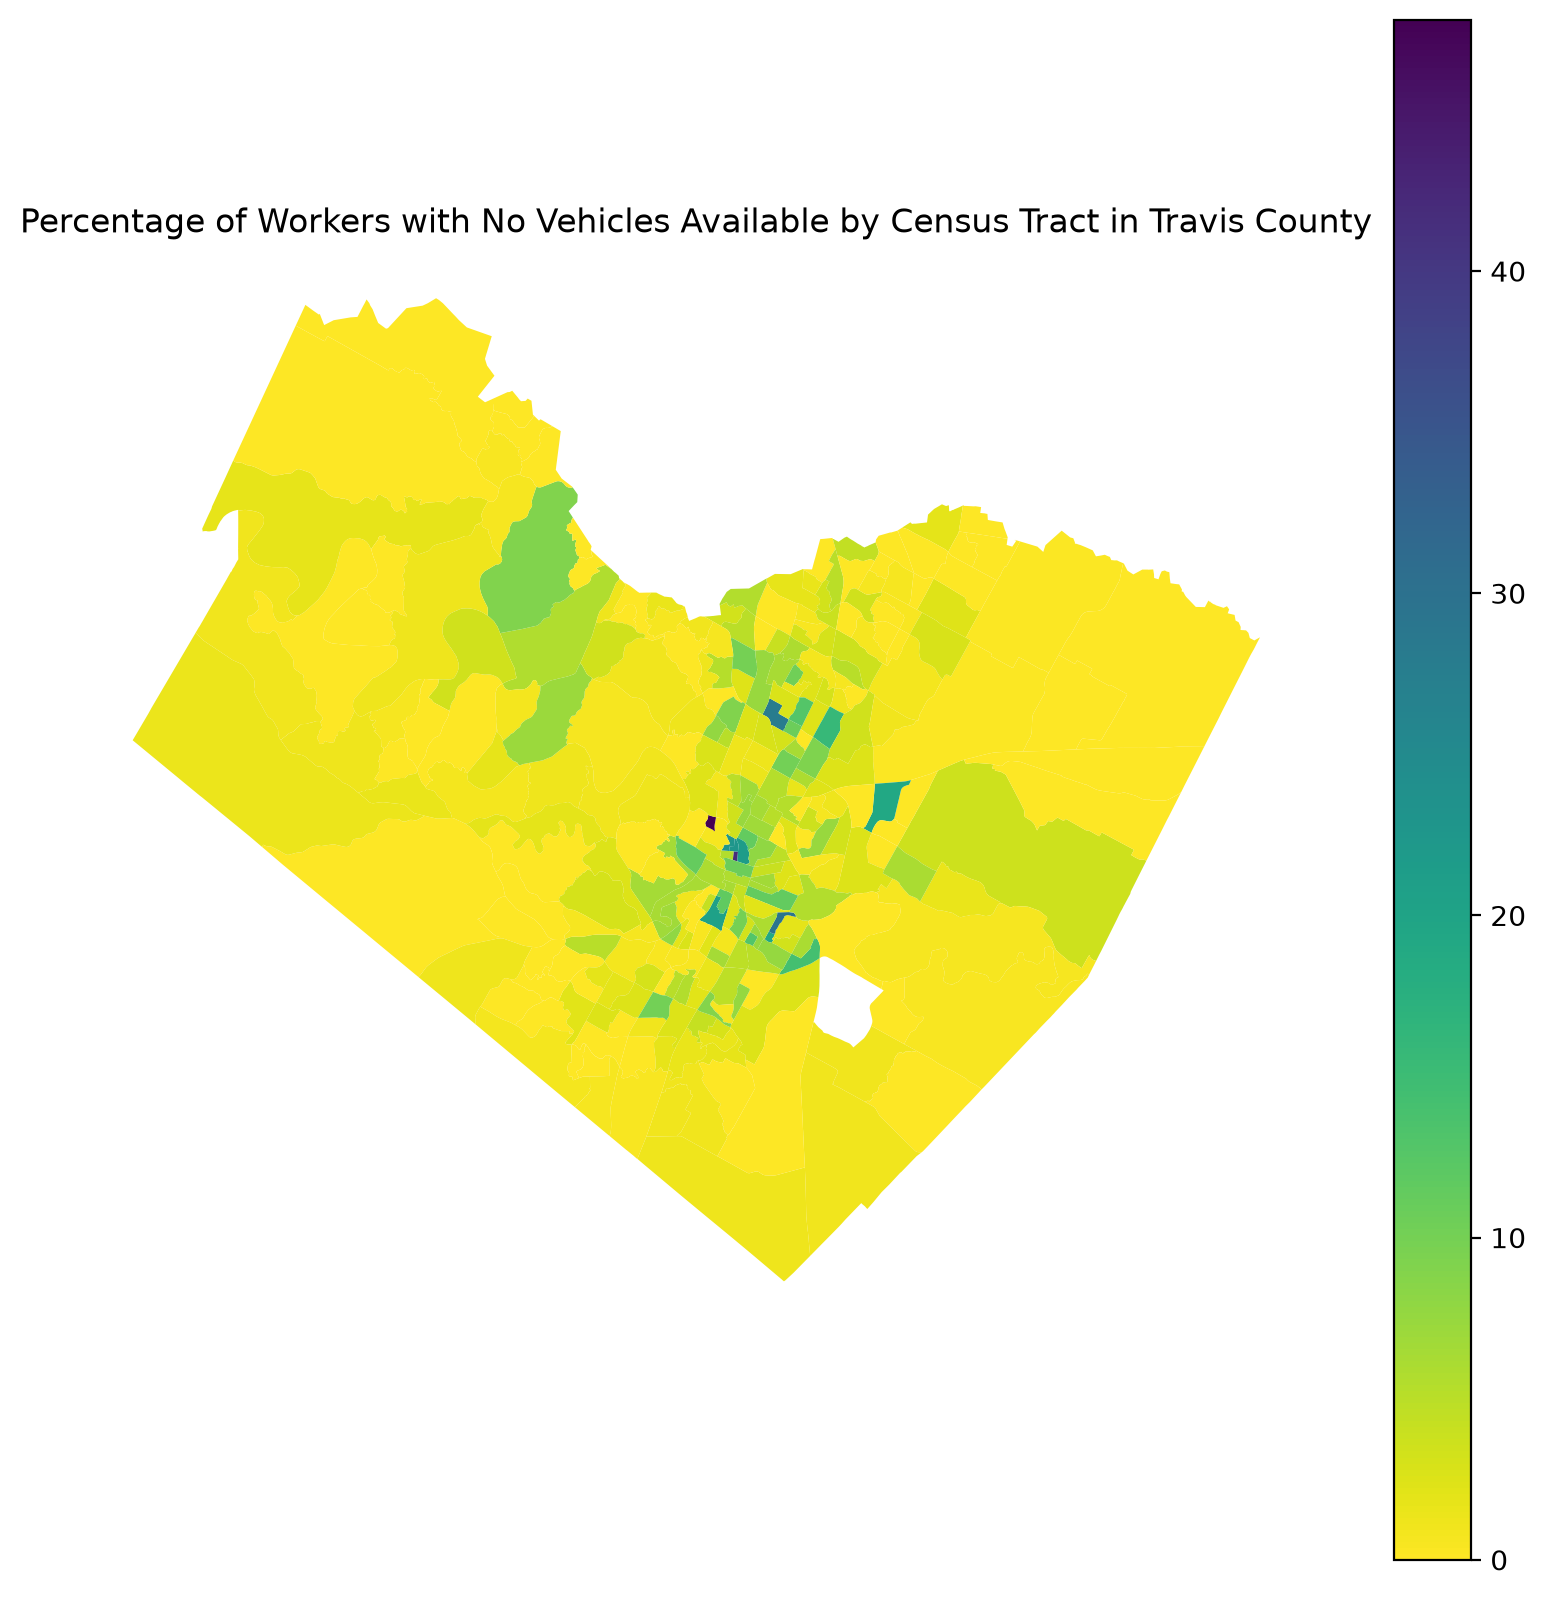

In [45]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_2.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Travis County")
plt.axis("off")
plt.show()

# 3. SNAP Map

In [46]:
df = pd.read_csv('snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48453000101,Census Tract 1.01; Travis County; Texas,2588,301,1056,311,1532,248,1117,183,...,(X),(X),(X),(X),26.2,10.5,15.8,6.9,58,10.7
2,1400000US48453000102,Census Tract 1.02; Travis County; Texas,1021,118,546,116,475,109,654,115,...,(X),(X),(X),(X),13.9,6.9,43.5,13.4,42.5,12.1
3,1400000US48453000203,Census Tract 2.03; Travis County; Texas,1246,93,207,73,1039,113,181,103,...,(X),(X),(X),(X),8.3,9.3,8.8,11.2,82.9,14.6
4,1400000US48453000204,Census Tract 2.04; Travis County; Texas,1397,144,307,75,1090,139,523,109,...,(X),(X),(X),(X),6.8,4.9,15,6.8,78.2,8.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,1400000US48453046700,Census Tract 467; Travis County; Texas,1118,112,305,93,813,137,816,171,...,(X),(X),(X),(X),4.3,4.2,37.1,11.9,58.6,11.4
287,1400000US48453046800,Census Tract 468; Travis County; Texas,4549,361,1035,234,3514,325,3418,520,...,(X),(X),(X),(X),1.8,1.9,23.3,6.9,74.9,7.1
288,1400000US48453046900,Census Tract 469; Travis County; Texas,2944,340,546,162,2398,355,2045,350,...,(X),(X),(X),(X),6.6,4.2,17.5,8,76,9
289,1400000US48453047000,Census Tract 470; Travis County; Texas,489,65,187,39,302,81,275,83,...,(X),(X),(X),(X),5,6.1,19.3,16.5,75.7,15.1


In [47]:
merged_3 = travis.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [48]:
merged_3["S2201_C04_001E"] = pd.to_numeric(
    merged_3["S2201_C04_001E"],
    errors="coerce"
)

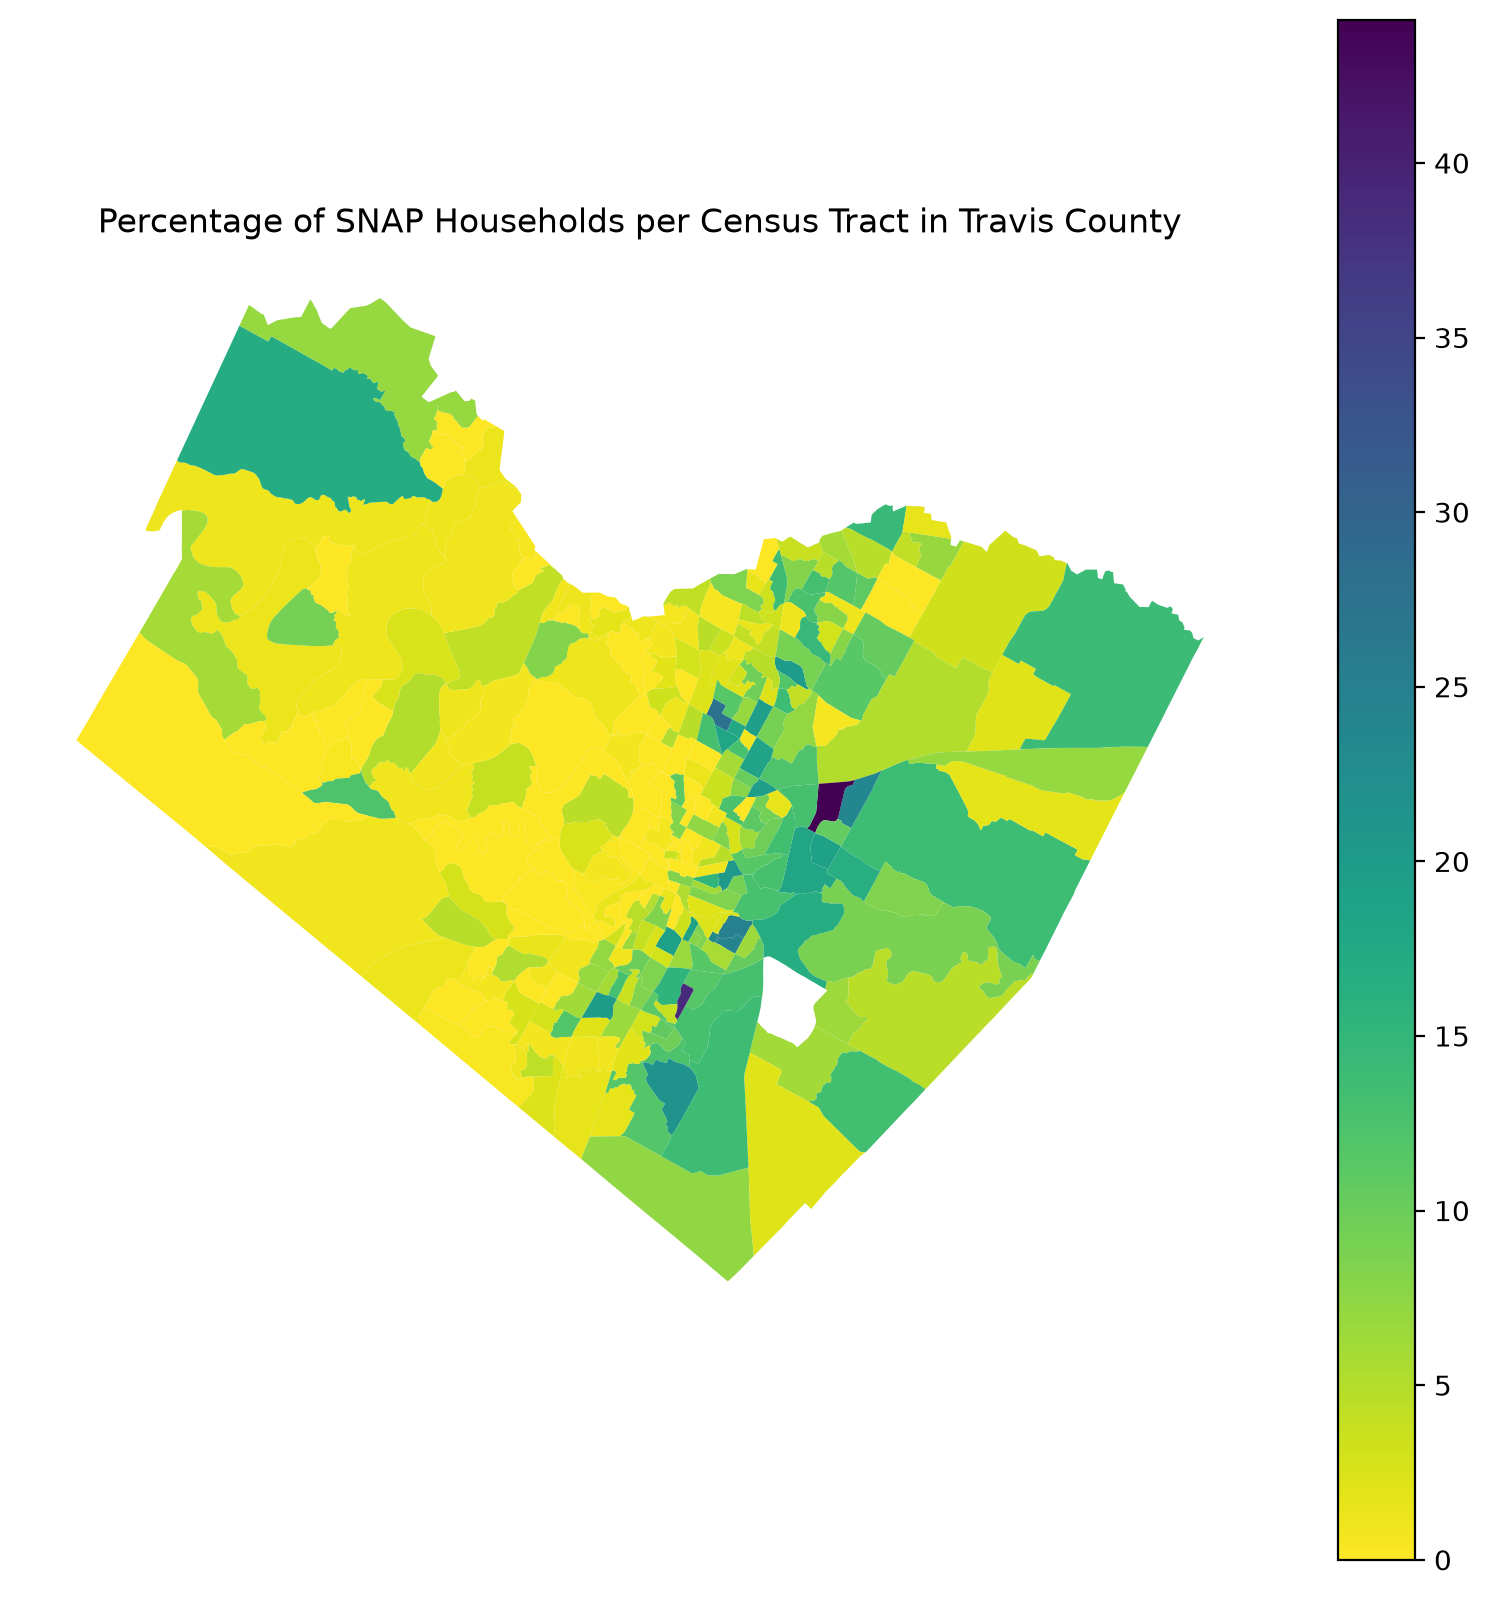

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_3.plot(
    column="S2201_C04_001E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households per Census Tract in Travis County")
plt.axis("off")
plt.show()

# 4. Low Income According to State Income

In [50]:
#State Median Income
#make sure column is numeric
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

#binary variable
merged["binary_income"] = (
    merged["S1903_C03_001E"] < 0.8*79721
).astype(int)
#1 if median income less than 0.8*79721
#0 if median income greater than or equal to 0.8*79721

# 5. Low Income According to Metropolitan Area

This map displays for each census tract that is in a metropolitan area that has a median income less than 80% of the metropolitan area's median income. Travis County is located in the Austin Metropolitan Area. The median income for this area for 2024 is $99, 897.

In [51]:
df_2= pd.read_csv('travis_metropolitan.csv')

In [52]:
gdf = gpd.read_file("tl_2024_48_tract.shp")
travis = gdf[gdf["COUNTYFP"] == "453"]

In [53]:
income = pd.read_csv("income_data.csv")

In [54]:
income["GEOID"] = income["GEO_ID"].str[-11:]

In [55]:
merged_2 = travis.merge(income, on="GEOID", how="left")

In [56]:
merged_2["S1903_C03_001E"] = pd.to_numeric(
    merged_2["S1903_C03_001E"],
    errors="coerce"
)

merged_2["binary_income_2"] = (
    merged_2["S1903_C03_001E"] < 0.8 * 99897
).astype(int)

In [57]:
[col for col in merged_2.columns if "S1903" in col]

['S1903_C01_001E',
 'S1903_C01_001M',
 'S1903_C01_002E',
 'S1903_C01_002M',
 'S1903_C01_003E',
 'S1903_C01_003M',
 'S1903_C01_004E',
 'S1903_C01_004M',
 'S1903_C01_005E',
 'S1903_C01_005M',
 'S1903_C01_006E',
 'S1903_C01_006M',
 'S1903_C01_007E',
 'S1903_C01_007M',
 'S1903_C01_008E',
 'S1903_C01_008M',
 'S1903_C01_009E',
 'S1903_C01_009M',
 'S1903_C01_010E',
 'S1903_C01_010M',
 'S1903_C01_011E',
 'S1903_C01_011M',
 'S1903_C01_012E',
 'S1903_C01_012M',
 'S1903_C01_013E',
 'S1903_C01_013M',
 'S1903_C01_014E',
 'S1903_C01_014M',
 'S1903_C01_015E',
 'S1903_C01_015M',
 'S1903_C01_016E',
 'S1903_C01_016M',
 'S1903_C01_017E',
 'S1903_C01_017M',
 'S1903_C01_018E',
 'S1903_C01_018M',
 'S1903_C01_019E',
 'S1903_C01_019M',
 'S1903_C01_020E',
 'S1903_C01_020M',
 'S1903_C01_021E',
 'S1903_C01_021M',
 'S1903_C01_022E',
 'S1903_C01_022M',
 'S1903_C01_023E',
 'S1903_C01_023M',
 'S1903_C01_024E',
 'S1903_C01_024M',
 'S1903_C01_025E',
 'S1903_C01_025M',
 'S1903_C01_026E',
 'S1903_C01_026M',
 'S1903_C01_

# 6. Low Income Tracts

In [58]:
poverty = pd.read_csv("travis_poverty.csv", skiprows=[1])

In [59]:
[col for col in poverty.columns if "S1701_C03_001E" in col]

[]

In [60]:
poverty["GEOID"] = poverty["GEO_ID"].str[-11:]

In [61]:
merged_3 = travis.merge(poverty, on="GEOID", how="left")

In [62]:
#merging SHP file
merged_3 = travis.merge(
    poverty,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [63]:
#merging SHP file
merged_3 = travis.merge(
    poverty,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [64]:
poverty = pd.read_csv("ACSST1Y2024.S1701-Data.csv", skiprows=[1])

[c for c in poverty.columns if "S1701" in c][:20]

['S1701_C01_001E',
 'S1701_C01_001M',
 'S1701_C01_002E',
 'S1701_C01_002M',
 'S1701_C01_003E',
 'S1701_C01_003M',
 'S1701_C01_004E',
 'S1701_C01_004M',
 'S1701_C01_005E',
 'S1701_C01_005M',
 'S1701_C01_006E',
 'S1701_C01_006M',
 'S1701_C01_007E',
 'S1701_C01_007M',
 'S1701_C01_008E',
 'S1701_C01_008M',
 'S1701_C01_009E',
 'S1701_C01_009M',
 'S1701_C01_010E',
 'S1701_C01_010M']

In [67]:
poverty["GEOID"] = poverty["GEO_ID"].str[-11:]

In [70]:

poverty["GEOID"] = poverty["GEO_ID"].str[-11:]

tracts = gpd.read_file("tl_2024_48_tract.shp")
dallas_tracts = tracts[tracts["COUNTYFP"] == "029"].copy()

merged_3 = dallas_tracts.merge(poverty, on="GEOID", how="left")

[c for c in merged_3.columns if "S1701_C03_001E" in c]

['S1701_C03_001E']

In [71]:
merged_3 = dallas_tracts.merge(poverty, on="GEOID", how="left")

In [72]:
merged_3["S1701_C03_001E"] = pd.to_numeric(
    merged_3["S1701_C03_001E"],
    errors="coerce"
)

In [73]:
#make sure values numeric
merged_3["S1701_C03_001E"] = pd.to_numeric(
    merged_3["S1701_C03_001E"],
    errors="coerce"
)

In [74]:
merged_3["binary_poverty"] = (
    merged_3["S1701_C03_001E"] >= 20.0
).astype(int)

c:\Users\saraz\anaconda3\envs\pandas\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [76]:
# merging all datasets 
#make copy of binary columns in first datafra,e
# mbined = merged.copy()
#match by tract ID
combined = merged.copy()

combined = combined.merge(
    merged_2[["GEOID", "binary_income_2"]],
    on="GEOID",
    how="left"
)

combined = combined.merge(
    merged_3[["GEOID", "binary_poverty"]],
    on="GEOID",
    how="left"
)

combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

In [77]:
#each condition as an or statement 
combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

<Axes: >

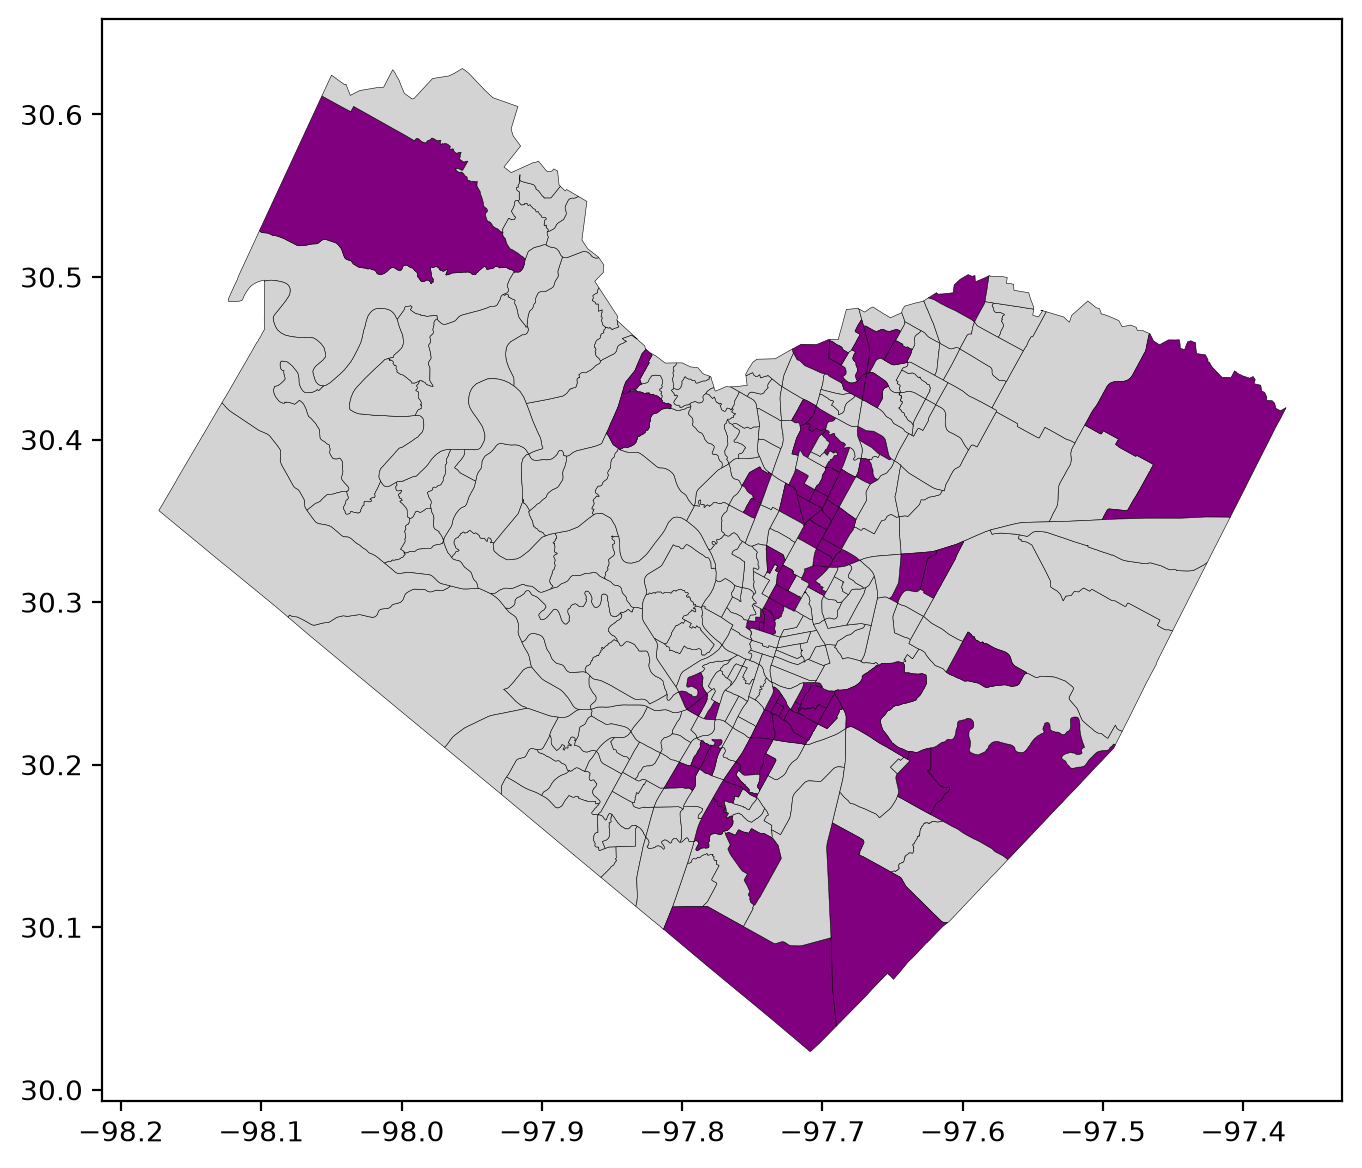

In [79]:
#import cmap
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["lightgrey", "purple"])

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

In [ ]:
#snap data import
# filter by state and county 

df = pd.read_csv("snap_retailer_location_data.csv")
travis_snap = df[(df["State"]== "TX") & (df["County"]=="TRAVIS")]

print(travis_snap.shape)
print(travis_snap["Store_Type"].value_counts())

(667, 17)
Store_Type
Convenience Store      385
Other                  110
Supermarket             70
Grocery Store           48
Super Store             47
Farmers and Markets      6
Specialty Store          1
Name: count, dtype: int64


In [81]:
# want to exclude Dollar General, Dollar Tree, CVS Pharmacy, CVS, Family Dollar,  Walgreens

excluded_others=["Dollar", "CVS", "Walgreen", "Walgrens", "Pharmacy"]

new_travis_data = travis_snap[(travis_snap["Store_Type"] == "Other") 
    & ~travis_snap["Store_Name"].str.contains("|".join(excluded_others), case=False, na=False)].copy()
print(new_travis_data.shape)
print(new_travis_data["Store_Name"].unique())

(13, 17)
<StringArray>
[                'Sanvi Austin Llc',     'La Placita Supermarket Llc 1',
           'WHEATSVILLE FOOD CO-OP',   'Farmshare Austin Mobile Market',
              'Filipino Asian Mart',                'Homefoods V Llc V',
                   'Fresh Plus one',    'Selam International Mart Cafe',
                      'Anand Bazar',                  'Tropical Market',
 'Masterson Super Mercado Mexicana',        'Africa's Best Food Market',
      'La Michoacana Meat Market 8']
Length: 13, dtype: str


In [82]:
kept_travis_others = ["La Placita Supermarket Llc", "WHEATSVILLE FOOD CO-O", "Farmshare Austin Mobile Marke"
                     , "Fresh Plus one", "Anand Bazar", "Tropical Market", "Masterson Super Mercado Mexicana",
                     "Africa's Best Food Market", "La Michoacana Meat Market"]
excluded_travis_others = ["Sanvi Austin Llc", "Filipino Asian Mart", "Homefoods V Llc V", "Selam International Mart Cafe"
                         ]

In [83]:
# filter out stores that are not grocery stores
included = ["Super Store","Supermarket","Grocery Store", "Farmers and Markets"]

cleaned_snap_data = travis_snap[travis_snap["Store_Type"].isin(included) | 
    travis_snap["Store_Name"].isin(kept_travis_others)].copy()

In [84]:
# remove columns that are not needed :"Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y"

final_cleaned_snap_data = cleaned_snap_data.drop(columns=["Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y", "Zip4"])

In [85]:
# Check for duplicate store names at the same address
dupes = final_cleaned_snap_data[cleaned_snap_data.duplicated(subset=["Store_Name", "Store_Street_Address"], keep=False)]
print(dupes[["Store_Name", "Store_Street_Address"]])

Empty DataFrame
Columns: [Store_Name, Store_Street_Address]
Index: []


In [86]:
# final csv file created
final_cleaned_snap_data.to_csv("cleaned_travis_snap_data.csv", index=False)
print(final_cleaned_snap_data.shape)
print(final_cleaned_snap_data[["Store_Name", "Latitude", "Longitude", "Store_Type"]].head())

(176, 11)
                  Store_Name   Latitude  Longitude     Store_Type
1529   Cuban Grocery Co #4 4  30.220797 -97.764580  Grocery Store
2317         Global Foodland  30.153116 -97.832718  Grocery Store
3075           RANDALLS 2471  30.303402 -97.764290    Supermarket
6919                 HEB 096  30.351864 -97.754860    Supermarket
11016          RANDALLS 1779  30.342083 -97.967712    Supermarket


In [87]:
%matplotlib inline

# read CSV
df = pd.read_csv("cleaned_travis_snap_data.csv")

# make sure longitude/latitude are numeric
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")

# remove rows with missing coordinates
df = df.dropna(subset=["Longitude", "Latitude"])

# create GeoDataFrame
geo_df = gpd.GeoDataFrame(
    df[[
        "Store_Name",
        "Store_Street_Address",
        "City",
        "Zip_Code",
        "Store_Type",
        "Latitude",
        "Longitude"
    ]],
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

geo_df.head()

,Store_Name,Store_Street_Address,City,Zip_Code,Store_Type,Latitude,Longitude,geometry
0,Cuban Grocery Co #4 4,4201 S Congress Ave,Austin,78745,Grocery Store,30.220797,-97.764580,POINT (-97.76458 30.2208)
1,Global Foodland,11501 Menchaca Rd,Austin,78748,Grocery Store,30.153116,-97.832718,POINT (-97.83272 30.15312)
2,RANDALLS 2471,2727 Exposition Blvd,Austin,78703,Supermarket,30.303402,-97.764290,POINT (-97.76429 30.3034)
3,HEB 096,7025 Village Center Dr,Austin,78731,Supermarket,30.351864,-97.754860,POINT (-97.75486 30.35186)
4,RANDALLS 1779,2301 Ranch Road,Lakeway,78734,Supermarket,30.342083,-97.967712,POINT (-97.96771 30.34208)


In [88]:
# make grocery store points from longitude and latitude
stores = gpd.GeoDataFrame(
    final_cleaned_snap_data,
    geometry=gpd.points_from_xy(
        final_cleaned_snap_data["Longitude"],
        final_cleaned_snap_data["Latitude"]
    ),
    crs="EPSG:4326"
)

# make sure tract map has a coordinate system
merged = merged.set_crs("EPSG:4269", allow_override=True)

# 3 convert both into meters for distance calculations
tracts_m = merged.to_crs("EPSG:3857")
stores_m = stores.to_crs("EPSG:3857")

# get tract centroids
tracts_m["centroid"] = tracts_m.geometry.centroid
centroids = tracts_m.set_geometry("centroid")

# find nearest grocery store to each tract centroid with join_nearest function
nearest = gpd.sjoin_nearest(
    centroids,
    stores_m[["Store_Name", "geometry"]],
    how="left",
    distance_col="distance_meters"
)

# convert meters to miles
nearest["distance_miles"] = nearest["distance_meters"] / 1609.34

In [89]:
nearest = nearest.sort_values("distance_meters").drop_duplicates("GEOID")

low_access_map = merged.merge(
    nearest[["GEOID", "distance_miles"]],
    on="GEOID",
    how="left"
)

low_access_map["binary_low_access"] = (
    low_access_map["distance_miles"] > 1
).astype(int)

In [90]:
#merge two datasets
final_map = combined.merge(
    low_access_map[["GEOID","binary_low_access"]],
    on="GEOID",
    how="left"
)

In [91]:
#conditional AND statement food desert indicator (low income and low access)
final_map["food_desert"] = (
    (final_map["binary_low_income"] == 1) & 
    (final_map["binary_low_access"] == 1)
)

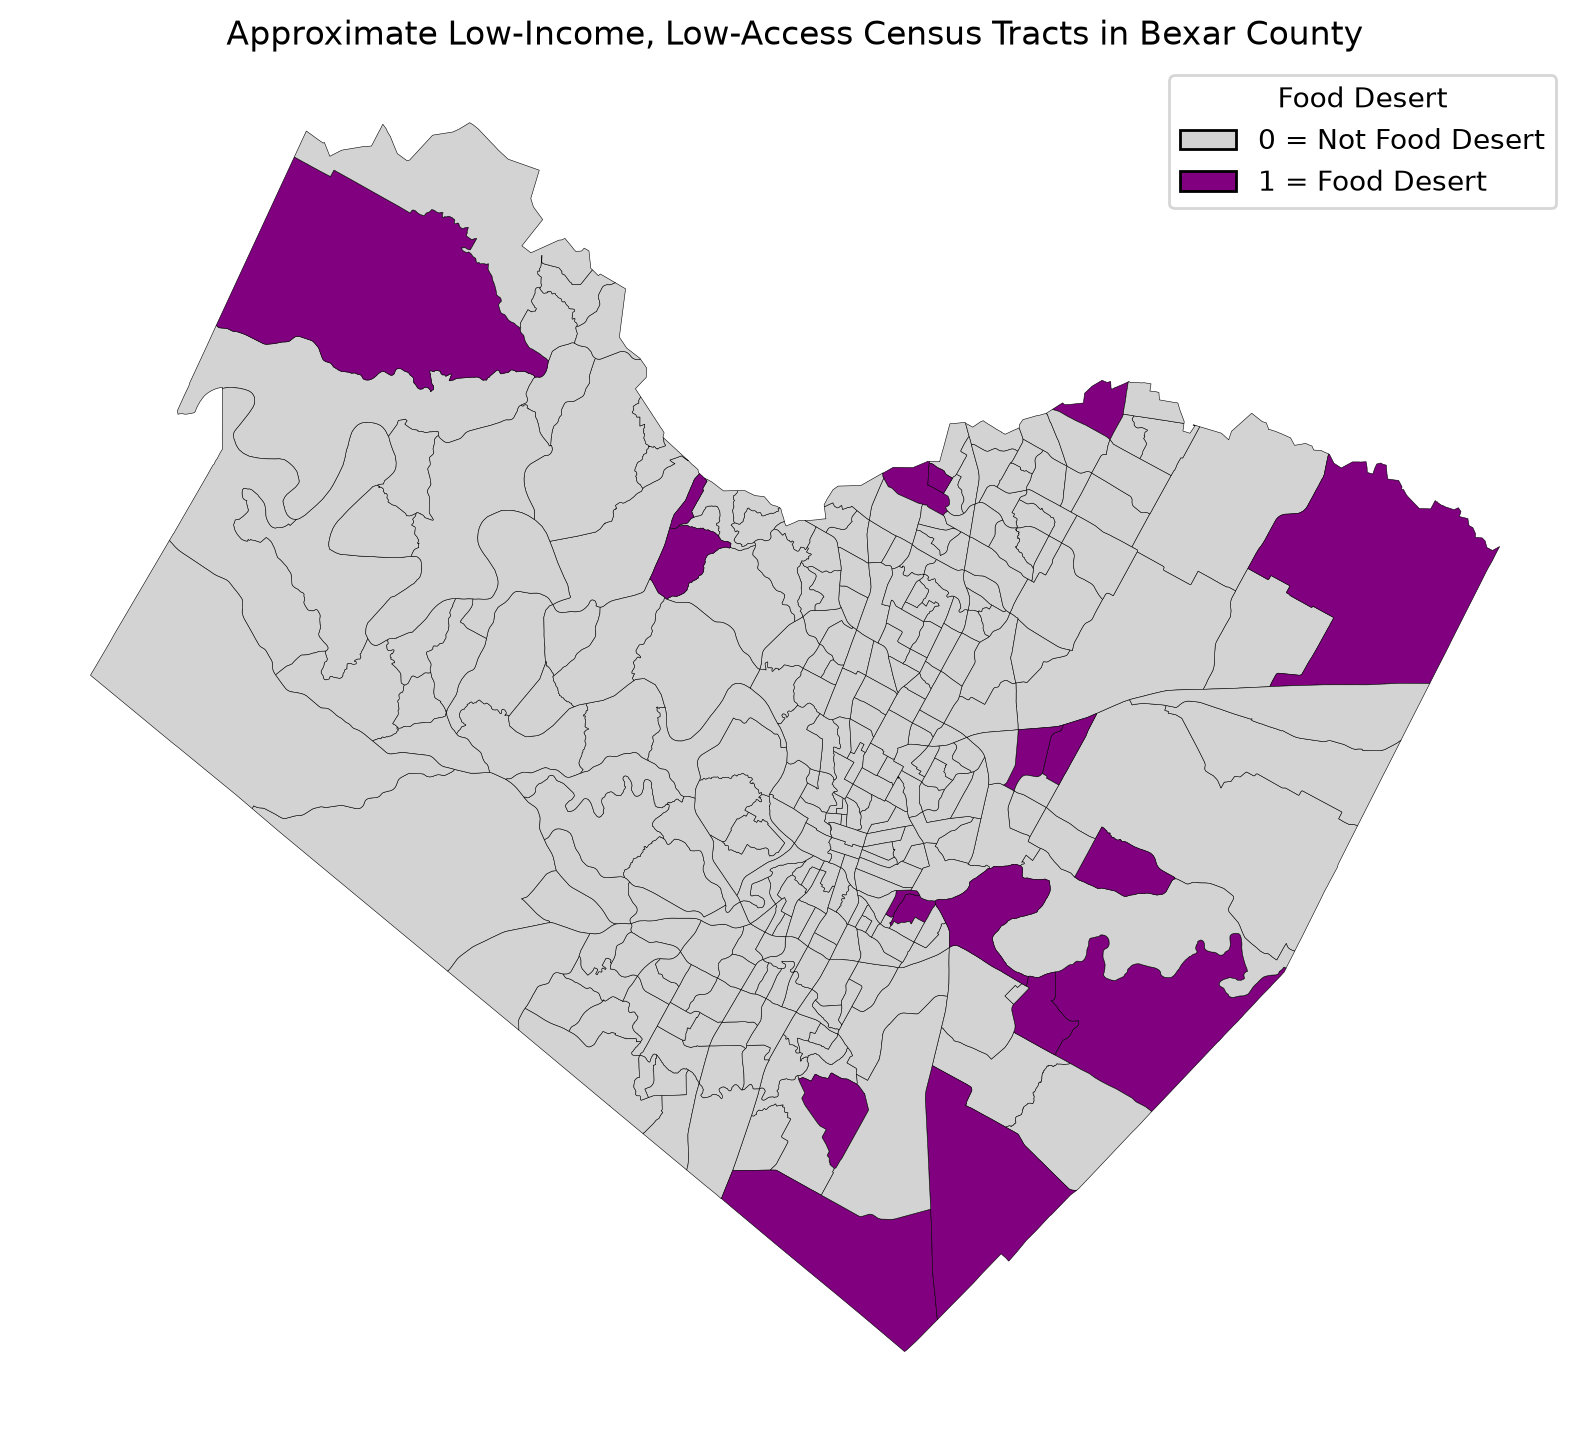

In [93]:
#binary map
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(10,10))

final_map.plot(
    column = "food_desert",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

#making a legend

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Food Desert"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Food Desert")
]

ax.legend(handles=legend_elements, title="Food Desert")
plt.title("Approximate Low-Income, Low-Access Census Tracts in Bexar County")
plt.axis("off")
plt.show()